In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

# Configuración
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("="*80)
print("📊 PREDICCIÓN DE APROBACIÓN - CÁLCULO 1")
print("🤖 REGRESIÓN LOGÍSTICA")
print("="*80)

# =============================================================================
# 1. CARGAR DATOS
# =============================================================================
print("\n📂 Cargando datos concatenados...")
try:
    df =pd.read_csv(r'D:\ArchivosHDD\GitHub\Machine-Learning\Clase_4\datos_concatenados.csv')

    print(f"✅ Datos cargados: {len(df):,} registros")
except FileNotFoundError:
    print("❌ No se encontró el archivo 'datosConcatenados.csv'")
    exit()

📊 PREDICCIÓN DE APROBACIÓN - CÁLCULO 1
🤖 REGRESIÓN LOGÍSTICA

📂 Cargando datos concatenados...
✅ Datos cargados: 72,740 registros


In [47]:
# =============================================================================
# 2. FILTRAR 
# =============================================================================
print("\n🔍 Filtrando Ecuaciones Diferenciales...")
mask = df['Asignatura'].str.upper().str.contains('ECUACIONES DIFERENCIALES', na=False)
df_ecuaciones_diferenciales = df[mask].copy()
print(f"✅ Registros de Ecuaciones Diferenciales: {len(df_ecuaciones_diferenciales):,}")
print(f"   Estudiantes únicos: {df_ecuaciones_diferenciales['ALUMNO_ID'].nunique():,}")



🔍 Filtrando Ecuaciones Diferenciales...
✅ Registros de Ecuaciones Diferenciales: 1,245
   Estudiantes únicos: 972


In [48]:
mask_remontada = df_ecuaciones_diferenciales['Segundo.Par']>df_ecuaciones_diferenciales['Primer.Par']
mask_firma=df_ecuaciones_diferenciales['Firma']>50
df_ecuaciones_diferenciales['Remontada'] = mask_remontada & mask_firma

In [49]:
# =============================================================================
# 2. FILTRAR 
# =============================================================================
print("\n🔍 Filtrando ...")
mask = df['Asignatura'].str.upper().str.contains('CALCULO 2', na=False)
df_calculo2 = df[mask].copy()
print(f"✅ Registros de Cálculo 2: {len(df_calculo2):,}")
print(f"   Estudiantes únicos: {df_calculo2['ALUMNO_ID'].nunique():,}")



🔍 Filtrando ...
✅ Registros de Cálculo 2: 892
   Estudiantes únicos: 892


In [50]:
df_anho_semestre = df_ecuaciones_diferenciales.groupby(['Anho', 'Semestre']).agg({'ALUMNO_ID': 'nunique'}).reset_index()

In [10]:
df_anho_semestre.head(10)

,Anho,Semestre,ALUMNO_ID
0,2024,2,647
1,2025,2,598


In [20]:
np.sum(mask_remontada)

np.int64(320)

In [19]:
np.sum(mask_firma)

np.int64(647)

In [41]:
df_ecuaciones_diferenciales['Remotada'].value_counts()

Remotada
False    1059
True      186
Name: count, dtype: int64

In [51]:
nuevo=df_ecuaciones_diferenciales.merge(df_calculo2, on='ALUMNO_ID', how='inner')

In [43]:
nuevo.head(10)

,ALUMNO_ID,Cod.Asign_x,Asignatura_x,Cod.Car.Sec_x,Cod.Curso_x,Convocatoria_x,Anho_x,Semestre_x,Doc.Firma_x,Aprobado_x,Anho.Firma_x,Primer.Par_x,Segundo.Par_x,Tercer.Par_x,TPLab._x,Lab._x,Proy._x,Pond.PP_x,Pond.SP_x,Pond.TPLab_x,Pond.Lab_x,Pond.Proy_x,Asis_x,Requisito_x,Firma_x,Primer.Rec_x,Segundo.Rec_x,Nota.Final_x,Archivo_Origen_x,FirmaCalculada_x,Carrera_x,Remotada,Cod.Asign_y,Asignatura_y,Cod.Car.Sec_y,Cod.Curso_y,Convocatoria_y,Anho_y,Semestre_y,Doc.Firma_y,Aprobado_y,Anho.Firma_y,Primer.Par_y,Segundo.Par_y,Tercer.Par_y,TPLab._y,Lab._y,Proy._y,Pond.PP_y,Pond.SP_y,Pond.TPLab_y,Pond.Lab_y,Pond.Proy_y,Asis_y,Requisito_y,Firma_y,Primer.Rec_y,Segundo.Rec_y,Nota.Final_y,Archivo_Origen_y,FirmaCalculada_y,Carrera_y
0,FIUNA_ALUMNO_012152,23032,ECUACIONES DIFERENCIALES,CIV-PLS23,3,1,2024,2,37227,N,2024,42,58,0,70,0,0,45,45,10,0,0,1,1,52.00,0,0,NaN,rendimiento_año_2024_ciclo_2_anon.xlsx,NaN,CIV,True,23022,CALCULO 2,CIV-PLS23,2,1,2025,1,36504,S,2024,69,50,0,81,0,0,42,42,16,0,0,1,1,44.00,0,0,1F-3,rendimiento_año_2025_ciclo_1_anon.xlsx,63.00,CIV
1,FIUNA_ALUMNO_012331,23032,ECUACIONES DIFERENCIALES,CIV-PLS23,3,1,2024,2,37227,N,2024,42,58,0,70,0,0,45,45,10,0,0,1,1,52.00,0,0,NaN,rendimiento_año_2024_ciclo_2_anon.xlsx,NaN,CIV,True,23022,CALCULO 2,CIV-PLS23,2,1,2025,1,36504,S,2024,69,50,0,81,0,0,42,42,16,0,0,1,1,44.00,0,0,1F-3,rendimiento_año_2025_ciclo_1_anon.xlsx,63.00,CIV
2,FIUNA_ALUMNO_012153,23032,ECUACIONES DIFERENCIALES,CIV-PLS23,3,1,2024,2,37227,N,2024,69,71,0,50,0,0,45,45,10,0,0,1,1,68.00,21,0,NaN,rendimiento_año_2024_ciclo_2_anon.xlsx,NaN,CIV,True,23022,CALCULO 2,CIV-PLS23,2,1,2025,1,36957,S,2024,74,37,0,63,0,0,42,42,16,0,0,1,1,40.00,0,0,1F-3,rendimiento_año_2025_ciclo_1_anon.xlsx,57.00,CIV
3,FIUNA_ALUMNO_012332,23032,ECUACIONES DIFERENCIALES,CIV-PLS23,3,1,2024,2,37227,N,2024,69,71,0,50,0,0,45,45,10,0,0,1,1,68.00,21,0,NaN,rendimiento_año_2024_ciclo_2_anon.xlsx,NaN,CIV,True,23022,CALCULO 2,CIV-PLS23,2,1,2025,1,36957,S,2024,74,37,0,63,0,0,42,42,16,0,0,1,1,40.00,0,0,1F-3,rendimiento_año_2025_ciclo_1_anon.xlsx,57.00,CIV
4,FIUNA_ALUMNO_012156,23032,ECUACIONES DIFERENCIALES,ECA-PLS23,3,1,2024,2,0,N,0,0,0,0,30,0,0,45,45,10,0,0,2,0,0.00,0,0,NaN,rendimiento_año_2024_ciclo_2_anon.xlsx,NaN,ECA,False,23022,CALCULO 2,ECA-PLS23,2,1,2025,1,36504,S,2024,90,50,0,100,0,0,42,42,16,0,0,1,1,60.00,75,0,2F-4,rendimiento_año_2025_ciclo_1_anon.xlsx,85.00,ECA
5,FIUNA_ALUMNO_012419,23032,ECUACIONES DIFERENCIALES,ECA-PLS23,3,1,2024,2,0,N,0,0,0,0,30,0,0,45,45,10,0,0,2,0,0.00,0,0,NaN,rendimiento_año_2024_ciclo_2_anon.xlsx,NaN,ECA,False,23022,CALCULO 2,ECA-PLS23,2,1,2025,1,36504,S,2024,90,50,0,100,0,0,42,42,16,0,0,1,1,60.00,75,0,2F-4,rendimiento_año_2025_ciclo_1_anon.xlsx,85.00,ECA
6,FIUNA_ALUMNO_012190,23032,ECUACIONES DIFERENCIALES,ELE-PLS23,3,1,2024,2,37728,N,2024,22,67,0,50,0,0,45,45,10,0,0,1,1,53.00,40,0,NaN,rendimiento_año_2024_ciclo_2_anon.xlsx,NaN,ELE,True,23022,CALCULO 2,ELE-PLS23,2,1,2025,1,36957,S,2024,67,87,0,69,0,0,42,42,16,0,0,1,1,53.00,0,0,1F-3,rendimiento_año_2025_ciclo_1_anon.xlsx,76.00,ELE
7,FIUNA_ALUMNO_012423,23032,ECUACIONES DIFERENCIALES,ELE-PLS23,3,1,2024,2,37728,N,2024,22,67,0,50,0,0,45,45,10,0,0,1,1,53.00,40,0,NaN,rendimiento_año_2024_ciclo_2_anon.xlsx,NaN,ELE,True,23022,CALCULO 2,ELE-PLS23,2,1,2025,1,36957,S,2024,67,87,0,69,0,0,42,42,16,0,0,1,1,53.00,0,0,1F-3,rendimiento_año_2025_ciclo_1_anon.xlsx,76.00,ELE
8,FIUNA_ALUMNO_012305,23032,ECUACIONES DIFERENCIALES,CIV-PLS23,3,1,2024,2,37227,N,2024,87,51,0,90,0,0,45,45,10,0,0,1,1,71.00,0,0,NaN,rendimiento_año_2024_ciclo_2_anon.xlsx,NaN,CIV,False,23022,CALCULO 2,CIV-PLS23,2,1,2025,1,36504,S,2024,67,67,0,69,0,0,42,42,16,0,0,1,1,47.00,0,0,1F-4,rendimiento_año_2025_ciclo_1_anon.xlsx,67.00,CIV
9,FIUNA_ALUMNO_012414,23032,ECUACIONES DIFERENCIALES,CIV-PLS23,3,1,2024,2,37227,N,2024,87,51,0,90,0,0,45,45,10,0,0,1,1,71.00,0,0,NaN,rendimiento_año_2024_ciclo_2_anon.xlsx,NaN,CIV,False,23022,CALCULO 2,CIV-PLS23,2,1,2025,1,36504,S,2024,67,67,0,69,0,0,42,42,16,0,0,1,1,47.00,0,0,1F-4,rendimiento_año_2025_cicl

In [46]:
nuevo.columns

Index(['ALUMNO_ID', 'Cod.Asign_x', 'Asignatura_x', 'Cod.Car.Sec_x',
       'Cod.Curso_x', 'Convocatoria_x', 'Anho_x', 'Semestre_x', 'Doc.Firma_x',
       'Aprobado_x', 'Anho.Firma_x', 'Primer.Par_x', 'Segundo.Par_x',
       'Tercer.Par_x', 'TPLab._x', 'Lab._x', 'Proy._x', 'Pond.PP_x',
       'Pond.SP_x', 'Pond.TPLab_x', 'Pond.Lab_x', 'Pond.Proy_x', 'Asis_x',
       'Requisito_x', 'Firma_x', 'Primer.Rec_x', 'Segundo.Rec_x',
       'Nota.Final_x', 'Archivo_Origen_x', 'FirmaCalculada_x', 'Carrera_x',
       'Remotada', 'Cod.Asign_y', 'Asignatura_y', 'Cod.Car.Sec_y',
       'Cod.Curso_y', 'Convocatoria_y', 'Anho_y', 'Semestre_y', 'Doc.Firma_y',
       'Aprobado_y', 'Anho.Firma_y', 'Primer.Par_y', 'Segundo.Par_y',
       'Tercer.Par_y', 'TPLab._y', 'Lab._y', 'Proy._y', 'Pond.PP_y',
       'Pond.SP_y', 'Pond.TPLab_y', 'Pond.Lab_y', 'Pond.Proy_y', 'Asis_y',
       'Requisito_y', 'Firma_y', 'Primer.Rec_y', 'Segundo.Rec_y',
       'Nota.Final_y', 'Archivo_Origen_y', 'FirmaCalculada_y', 'Carrera

In [54]:
X=nuevo[['Nota.Final_y', 'Primer.Par_x']]
X['Nota.Final_y']=X['Nota.Final_y'].apply(lambda x: x[-1] if isinstance(x, str) else x)
y=nuevo[['Remontada']]

In [55]:
X.head()

,Nota.Final_y,Primer.Par_x
0,3,42
1,3,42
2,3,69
3,3,69
4,4,0


In [59]:
y.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 304 entries, 0 to 303
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Remontada  304 non-null    bool 
dtypes: bool(1)
memory usage: 432.0 bytes


In [63]:
X['Primer.Par_x'].astype(float)

0     42.00
1     42.00
2     69.00
3     69.00
4      0.00
       ... 
299   96.00
300   76.00
301   76.00
302   78.00
303   78.00
Name: Primer.Par_x, Length: 304, dtype: float64

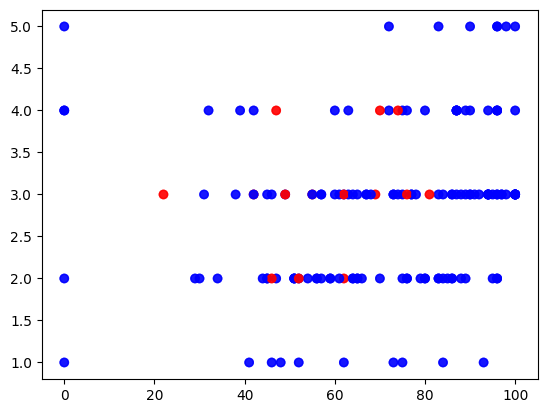

In [65]:
plt.scatter(X['Primer.Par_x'].astype(float), X['Nota.Final_y'].astype(float), c=y['Remontada'], cmap='bwr', alpha=0.7)

(array([ 20.,   0.,  90.,   0.,   0., 124.,   0.,  50.,   0.,  16.]),
 array([1. , 1.4, 1.8, 2.2, 2.6, 3. , 3.4, 3.8, 4.2, 4.6, 5. ]),
 <BarContainer object of 10 artists>)

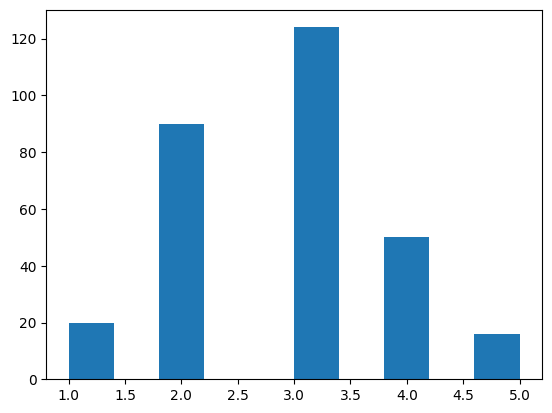

In [74]:
plt.hist(nuevo['Nota.Final_y'].apply(lambda x: x[-1] if isinstance(x, str) else x).astype(float))

In [76]:
nuevo[nuevo['Nota.Final_y'].apply(lambda x: x[-1] if isinstance(x, str) else x).astype(float)==1.0]

,ALUMNO_ID,Cod.Asign_x,Asignatura_x,Cod.Car.Sec_x,Cod.Curso_x,Convocatoria_x,Anho_x,Semestre_x,Doc.Firma_x,Aprobado_x,Anho.Firma_x,Primer.Par_x,Segundo.Par_x,Tercer.Par_x,TPLab._x,Lab._x,Proy._x,Pond.PP_x,Pond.SP_x,Pond.TPLab_x,Pond.Lab_x,Pond.Proy_x,Asis_x,Requisito_x,Firma_x,Primer.Rec_x,Segundo.Rec_x,Nota.Final_x,Archivo_Origen_x,FirmaCalculada_x,Carrera_x,Remontada,Cod.Asign_y,Asignatura_y,Cod.Car.Sec_y,Cod.Curso_y,Convocatoria_y,Anho_y,Semestre_y,Doc.Firma_y,Aprobado_y,Anho.Firma_y,Primer.Par_y,Segundo.Par_y,Tercer.Par_y,TPLab._y,Lab._y,Proy._y,Pond.PP_y,Pond.SP_y,Pond.TPLab_y,Pond.Lab_y,Pond.Proy_y,Asis_y,Requisito_y,Firma_y,Primer.Rec_y,Segundo.Rec_y,Nota.Final_y,Archivo_Origen_y,FirmaCalculada_y,Carrera_y
10,False,23032,ECUACIONES DIFERENCIALES,ECA-PLS23,3,1,2025,2,0,N,0,52,29,0,18,0,0,40,40,20,0,0,1,0,36.00,0,0,NaN,rendimiento_año_2025_ciclo_2_anon.xlsx,NaN,ECA,False,23022,CALCULO 2,ECA-PLS23,2,1,2025,1,38395,N,2025,24,33,0,94,0,0,42,42,16,0,0,1,1,60.00,75,0,2F-1,rendimiento_año_2025_ciclo_1_anon.xlsx,60.00,ECA
11,False,23032,ECUACIONES DIFERENCIALES,ECA-PLS23,3,1,2025,2,0,N,0,52,29,0,18,0,0,40,40,20,0,0,1,0,36.00,0,0,NaN,rendimiento_año_2025_ciclo_2_anon.xlsx,NaN,ECA,False,23022,CALCULO 2,ECA-PLS23,2,1,2025,1,38395,N,2025,24,33,0,94,0,0,42,42,16,0,0,1,1,60.00,75,0,2F-1,rendimiento_año_2025_ciclo_1_anon.xlsx,60.00,ECA
18,False,23032,ECUACIONES DIFERENCIALES,CIV-PLS23,3,1,2025,2,0,N,0,0,0,0,5,0,0,40,40,20,0,0,2,0,1.00,0,0,NaN,rendimiento_año_2025_ciclo_2_anon.xlsx,NaN,CIV,False,23022,CALCULO 2,CIV-PLS23,2,1,2025,1,38395,N,2025,36,53,0,56,0,0,42,42,16,0,0,1,1,61.00,72,0,2F-1,rendimiento_año_2025_ciclo_1_anon.xlsx,61.00,CIV
19,False,23032,ECUACIONES DIFERENCIALES,CIV-PLS23,3,1,2025,2,0,N,0,0,0,0,5,0,0,40,40,20,0,0,2,0,1.00,0,0,NaN,rendimiento_año_2025_ciclo_2_anon.xlsx,NaN,CIV,False,23022,CALCULO 2,CIV-PLS23,2,1,2025,1,38395,N,2025,36,53,0,56,0,0,42,42,16,0,0,1,1,61.00,72,0,2F-1,rendimiento_año_2025_ciclo_1_anon.xlsx,61.00,CIV
38,False,23032,ECUACIONES DIFERENCIALES,CIV-PLS23,3,1,2025,2,0,N,0,48,33,0,45,0,0,40,40,20,0,0,1,1,41.00,21,0,NaN,rendimiento_año_2025_ciclo_2_anon.xlsx,NaN,CIV,False,23022,CALCULO 2,CIV-PLS23,2,1,2025,1,38181,N,2025,69,43,0,40,0,0,42,42,16,0,0,1,1,53.00,0,0,2F-1,rendimiento_año_2025_ciclo_1_anon.xlsx,53.00,CIV
39,False,23032,ECUACIONES DIFERENCIALES,CIV-PLS23,3,1,2025,2,0,N,0,48,33,0,45,0,0,40,40,20,0,0,1,1,41.00,21,0,NaN,rendimiento_año_2025_ciclo_2_anon.xlsx,NaN,CIV,False,23022,CALCULO 2,CIV-PLS23,2,1,2025,1,38181,N,2025,69,43,0,40,0,0,42,42,16,0,0,1,1,53.00,0,0,2F-1,rendimiento_año_2025_ciclo_1_anon.xlsx,53.00,CIV
60,False,23032,ECUACIONES DIFERENCIALES,CIV-PLS23,3,1,2025,2,0,N,0,46,35,0,50,0,0,40,40,20,0,0,1,1,42.00,0,0,NaN,rendimiento_año_2025_ciclo_2_anon.xlsx,NaN,CIV,False,23022,CALCULO 2,CIV-PLS23,2,1,2025,1,38395,N,2025,40,27,0,100,0,0,42,42,16,0,0,1,1,60.00,65,0,2F-1,rendimiento_año_2025_ciclo_1_anon.xlsx,60.00,CIV
61,False,23032,ECUACIONES DIFERENCIALES,CIV-PLS23,3,1,2025,2,0,N,0,46,35,0,50,0,0,40,40,20,0,0,1,1,42.00,0,0,NaN,rendimiento_año_2025_ciclo_2_anon.xlsx,NaN,CIV,False,23022,CALCULO 2,CIV-PLS23,2,1,2025,1,38395,N,2025,40,27,0,100,0,0,42,42,16,0,0,1,1,60.00,65,0,2F-1,rendimiento_año_2025_ciclo_1_anon.xlsx,60.00,CIV
90,False,23032,ECUACIONES DIFERENCIALES,ELE-PLS23,3,1,2025,2,38545,N,2025,84,48,0,58,0,0,40,40,20,0,0,1,1,74.00,73,0,NaN,rendimiento_año_2025_ciclo_2_anon.xlsx,NaN,ELE,False,23022,CALCULO 2,ELE-PLS23,2,1,2025,1,38181,N,2025,62,37,0,63,0,0,42,42,16,0,0,1,1,52.00,0,0,"1F-1,2F-1",rendimiento_año_2025_ciclo_1_anon.xlsx,52.00,ELE
91,False,23032,ECUACIONES DIFERENCIALES,ELE-PLS23,3,1,2025,2,38545,N,2025,84,48,0,58,0,0,40,40,20,0,0,1,1,74.00,73,0,NaN,rendimiento_año_2025_ciclo_2_anon.xlsx,NaN,ELE,False,23022,CALCULO 2,ELE-PLS23,2,1,2025,1,38181,N,2025,62,37,0,63,0,0,42,42,16,0,0,1,1,52.00,0,0,"1F-1,2F-1",rendimiento_año_2025_ciclo_1_anon.xlsx,52.00,ELE


In [82]:
NoNulos=X.isnull().any(axis=1)
Xl=X[np.logical_not(NoNulos)]
yl=y[np.logical_not(NoNulos)]

In [89]:
modelo=LogisticRegression(class_weight='balanced', random_state=42)
modelo.fit(Xl.values,yl.values)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [90]:
modelo.coef_    

array([[ 0.46767293, -0.039656  ]])

In [91]:
ypre=modelo.predict(Xl.values)

In [92]:
confusion_matrix(yl.values, ypre)

array([[186,  86],
       [  8,  20]])

In [94]:
print(classification_report(yl.values, ypre))  

              precision    recall  f1-score   support

       False       0.96      0.68      0.80       272
        True       0.19      0.71      0.30        28

    accuracy                           0.69       300
   macro avg       0.57      0.70      0.55       300
weighted avg       0.89      0.69      0.75       300

